In [1]:
#from google.colab import drive
#drive.mount('/content/drive')
import pandas as pd

import matplotlib.pyplot as plt
from   matplotlib.path import Path
from  matplotlib.lines import Line2D

import numpy as np
import numpy.lib.recfunctions as rfn
from   numpy.polynomial.legendre import legval

import plotly.graph_objects as go
from ipywidgets import interact, IntSlider

from scipy.special import eval_legendre,legendre,factorial
from scipy.optimize import curve_fit, least_squares, differential_evolution

from Fonctions.Vopt import V_opt
from Fonctions.Metriques import rsq, rmse, mae
from Fonctions.Affichage import plot_interactif

# Import des données

In [2]:
# Tableau : Ne-HCN
Ne = np.genfromtxt("Data/Ne-HCN.txt",
                   delimiter=",", names=True, dtype=None, encoding="utf-8")

# Conversion des µEh en mEh
energy_mEh = Ne['Energy'] * 1e-3
# Ajout de la colonne en Eh
Ne = rfn.append_fields(Ne, names='Energy_mEh', data=energy_mEh, usemask=False)

# Parametres donnés par Toczylowski
params_Ne = np.array([ 1.39799,   0.06304,   0.10472,   0.10103,   0.04239, -0.00674,  # b
                      -33692.705,-209959.32,-16394.597,-107262.52,                     # c
                       13.60561,  0.87434,   2.39464,   0.60195,   0.31713,  0.05930,  # d
                       0.10500,  -0.06621,  -0.05328,   0.01479,   0.00609, -0.00197,  # g0
                      -0.03368,   0.02788,   0.02191,  -0.00483,  -0.00308,  0.00011,  # g1
                       0.00374,  -0.00401,  -0.00298,   0.00070,   0.00054,  0.00004,  # g2
                      -0.000154,  0.000203,  0.000141, -0.000046, -0.000033,-0.000002])# g3

# Implémentation des fonctions

In [3]:
def f6_opt(x):
  y = 1.0 + x * (1.0 + x * (0.5 + x * (1.0/6.0 + x * (1.0/24.0 + x * (1.0/120.0 + x / 720.0)))))
  return 1.0 - np.exp(-x) * y

def f7_opt(x):
  y = 1.0 + x * (1.0 + x * (0.5 + x * (1.0/6.0 + x * (1.0/24.0 + x * (1.0/120.0 + x * (1.0/720.0 + x / 5040.0))))))
  return 1.0 - np.exp(-x) * y

In [4]:
def V_opt(p, R, Theta):
  R = np.asarray(R, dtype=float)
  # On calcule ces valeurs car utiles plusieurs fois
  cosTh = np.cos(np.deg2rad(np.asarray(Theta, dtype=float)))

  # Paramètres
  b  = p[0:6]                            # b0, b1, b2, b3, b4, b5
  c  = p[6:10]                           # c0, c1, c2, c3
  d  = p[10:16]                          # d0, d1, d2, d3, d4, d5
  g0 = np.asarray(p[16:22], dtype=float) # g00, g01, g02, g03, g04, g05
  g1 = np.asarray(p[22:28], dtype=float) # g10, g11, g12, g13, g14, g15
  g2 = np.asarray(p[28:34], dtype=float) # g20, g21, g22, g23, g24, g25
  g3 = np.asarray(p[34:40], dtype=float) # g30, g31, g32, g33, g34, g35

  # X(theta) ------------------------------------ #
  # --------------------------------------------- #
  X_b = legval(cosTh, b)
  X_d = legval(cosTh, d)

  X_bR = X_b * R
  abs_BR = np.abs(X_bR)
  # --------------------------------------------- #

  # G(R,theta) ---------------------------------- #
  # --------------------------------------------- #
  i = np.arange(6)
  g = g0[i, None] + R * (g1[i, None] + R * (g2[i, None] + R * g3[i, None]))
  Pl = np.array([eval_legendre(l, cosTh) for l in range(6)])
  # G = np.sum(g * Pl, axis=0)
  # ------------------------------------------- #

  # Short-Range
  exp_val = np.clip(X_d-X_bR,-200,200) # Bloquage des valeurs trop grandes/petites
  V_sh = np.sum(g * Pl, axis=0) * np.exp(exp_val)

  # Asymptotic
  inv_R = 1.0/R
  inv_R6 = inv_R * inv_R * inv_R * inv_R * inv_R * inv_R
  inv_R7 = inv_R6 * inv_R

  V_as = (f6_opt(abs_BR) * legval(cosTh,[c[0],0,c[2]]) * inv_R6
        + f7_opt(abs_BR) * legval(cosTh,[0,c[1],0,c[3]]) * inv_R7)

  V_total = V_sh + V_as

  # Pour ne pas renvoyer NaN en cas d'erreur
  V_total = np.nan_to_num(V_total, nan=1e100, posinf=1e100, neginf=-1e100)
  # Bloquage des valeurs trop grandes
  V_total = np.clip(V_total, -1e100, 1e100)
  
  return V_total # Energie renvoyée en mEh

# Fonctions de métriques

In [5]:
def rsq(y, f):
  y = np.asarray(y)
  f = np.asarray(f)
  stot = np.sum((y-np.mean(y))**2)
  sres = np.sum((y-f)**2)
  return 1.0 - sres/stot


# y == valeurs tabulées

# f == f(x, y, popt)

In [6]:
def rmse(y, f):
    y = np.asarray(y)
    f = np.asarray(f)
    return np.sqrt(np.mean((y-f)**2))

In [7]:
def mae(y,f):
    y = np.asarray(y)
    f = np.asarray(f)
    return np.mean(np.abs(y-f))

# Fonction d'affichage

In [8]:
def plot_interactif(
    model,
    params,
    fixed_vals,
    x,
    data,
    fixed_col,
    x_col,
    y_col,
    title="Graphique interactif",
    fixed_first=True
):

    fig = go.Figure()

    for i, val in enumerate(fixed_vals):

        # ordre des variables
        if fixed_first:
            y_model = model(params, np.full_like(x, val), x)
        else:
            y_model = model(params, x, np.full_like(x, val))

        # données
        mask = np.isclose(data[fixed_col], val)

        x_data = data[x_col][mask]
        y_data = data[y_col][mask]

        order = np.argsort(x_data)

        visible = (i == 0)

        fig.add_trace(
            go.Scatter(
                x=x,
                y=y_model,
                mode='lines',
                name='Modèle',
                visible=visible
            )
        )

        fig.add_trace(
            go.Scatter(
                x=x_data[order],
                y=y_data[order],
                mode='markers',
                name='Données',
                visible=visible
            )
        )

    steps = []

    for i, val in enumerate(fixed_vals):

        vis = [False] * (2 * len(fixed_vals))

        vis[2*i] = True
        vis[2*i+1] = True

        steps.append(
            dict(
                method="update",
                args=[
                    {"visible": vis},
                    {"title": f"{fixed_col} = {val}"}
                ],
                label=str(val)
            )
        )

    fig.update_layout(
        title=title,
        sliders=[dict(steps=steps)],
        template="plotly_white",
        width=600,
        height=400,
        uirevision=True
    )

    fig.show()

# Méthode 1 : curve_fit

In [9]:
def V_curvefit(vars, *p):
    R, Theta = vars
    return V_opt(p, R, Theta)

## Calculs

In [10]:
R = np.asarray(Ne["R"], dtype=float)
Theta = np.asarray(Ne["Theta"], dtype=float)
V_table = np.asarray(Ne["Energy_mEh"], dtype=float)
R.shape, Theta.shape, V_table.shape

((151,), (151,), (151,))

In [11]:
#params_init_cf = 10 * np.random.rand(40) - 5
#print(params_init_cf)
params_opt_cf, params_cov = curve_fit(V_curvefit, (R, Theta), V_table,
                                      p0=params_Ne, maxfev=1000000,
                                      method="lm")
params_opt_cf_sigma, params_cov = curve_fit(V_curvefit, (R, Theta), V_table,
                                      p0=params_Ne, maxfev=1000000,
                                      method="lm", sigma=V_table)

In [12]:
b  = params_opt_cf[0:6]   # b0, b1, b2, b3, b4, b5
c  = params_opt_cf[6:10]  # c0, c1, c2, c3
d  = params_opt_cf[10:16] # d0, d1, d2, d3, d4, d5
g0 = params_opt_cf[16:22] # g00, g01, g02, g03, g04, g05
g1 = params_opt_cf[22:28] # g10, g11, g12, g13, g14, g15
g2 = params_opt_cf[28:34] # g20, g21, g22, g23, g24, g25
g3 = params_opt_cf[34:40] # g30, g31, g32, g33, g34, g35

print(f"[b0,b1,b2,b3,b4,b5]       = [{b[0]}, {b[1]}, {b[2]}, {b[3]}, {b[4]}, {b[5]}]")
print(f"[c0,c1,c2,c3]             = [{c[0]}, {c[1]}, {c[2]}, {c[3]}]")
print(f"[d0,d1,d2,d3,d4,d5]       = [{d[0]}, {d[1]}, {d[2]}, {d[3]}, {d[4]}, {d[5]}]")
print(f"[g00,g01,g02,g03,g04,g05] = [{g0[0]}, {g0[1]}, {g0[2]}, {g0[3]}, {g0[4]}, {g0[5]}]")
print(f"[g10,g11,g12,g13,g14,g15] = [{g1[0]}, {g1[1]}, {g1[2]}, {g1[3]}, {g1[4]}, {g1[5]}]")
print(f"[g20,g21,g22,g23,g24,g25] = [{g2[0]}, {g2[1]}, {g2[2]}, {g2[3]}, {g2[4]}, {g2[5]}]")
print(f"[g30,g31,g32,g33,g34,g35] = [{g3[0]}, {g3[1]}, {g3[2]}, {g3[3]}, {g3[4]}, {g3[5]}]")

[b0,b1,b2,b3,b4,b5]       = [1.3798472890167888, 0.07472955177173786, 0.11463399064169114, 0.09664061365421697, 0.04825021338207894, -0.022462487236268425]
[c0,c1,c2,c3]             = [-32839.351078849526, -206089.1473842573, -16095.84872073697, -111544.53725898053]
[d0,d1,d2,d3,d4,d5]       = [13.482389671979783, 0.6831330387887867, 2.2968592188582844, 0.5515761403407088, 0.33918002199475716, -0.02228300384629804]
[g00,g01,g02,g03,g04,g05] = [0.10847824830983091, -0.0507757971487146, -0.054340708274480044, 0.007093716585741757, 0.006101417882764159, 0.002974487318188961]
[g10,g11,g12,g13,g14,g15] = [-0.03475463021378874, 0.024060011018696845, 0.024532506679458797, -0.0007986944512043396, -0.0030140961914325204, -0.0019284409585943582]
[g20,g21,g22,g23,g24,g25] = [0.0038309887460221148, -0.0036850873280246527, -0.003530849354460596, 5.1819450958993793e-05, 0.0005747743317037476, 0.00033046018562138445]
[g30,g31,g32,g33,g34,g35] = [-0.00015541584468724826, 0.0001910474952009937, 0.00017

In [13]:
print(params_opt_cf)
print(params_opt_cf_sigma)

[ 1.37984729e+00  7.47295518e-02  1.14633991e-01  9.66406137e-02
  4.82502134e-02 -2.24624872e-02 -3.28393511e+04 -2.06089147e+05
 -1.60958487e+04 -1.11544537e+05  1.34823897e+01  6.83133039e-01
  2.29685922e+00  5.51576140e-01  3.39180022e-01 -2.22830038e-02
  1.08478248e-01 -5.07757971e-02 -5.43407083e-02  7.09371659e-03
  6.10141788e-03  2.97448732e-03 -3.47546302e-02  2.40600110e-02
  2.45325067e-02 -7.98694451e-04 -3.01409619e-03 -1.92844096e-03
  3.83098875e-03 -3.68508733e-03 -3.53084935e-03  5.18194510e-05
  5.74774332e-04  3.30460186e-04 -1.55415845e-04  1.91047495e-04
  1.71496183e-04 -1.08812801e-05 -3.83703341e-05 -1.60209466e-05]
[ 1.34941965e+00  4.24293197e-02  5.82061692e-02  4.94689213e-02
  2.65207642e-03 -1.31049521e-02 -3.15706680e+04 -2.86617158e+05
 -1.43102553e+04 -7.33385741e+04  1.34205382e+01  8.89380236e-01
  1.68037499e+00  5.24242689e-01  7.87487946e-02 -5.69507331e-02
  1.15642950e-01 -8.33740562e-02  2.64055585e-02  1.05085337e-03
  1.99197542e-02  8.4560

In [14]:
print(np.array2string(
    params_opt_cf_sigma,
    formatter={'float_kind': lambda x: f"{x:.12f}"}
))

[1.349419652039 0.042429319676 0.058206169164 0.049468921259
 0.002652076418 -0.013104952147 -31570.667985317177 -286617.158490778646
 -14310.255255060631 -73338.574064862798 13.420538151279 0.889380235552
 1.680374990659 0.524242688742 0.078748794578 -0.056950733122
 0.115642950395 -0.083374056191 0.026405558504 0.001050853367
 0.019919754233 0.008456052201 -0.038747428560 0.034114487746
 -0.006396291478 -0.001992168760 -0.007438098143 -0.003010745988
 0.004473548874 -0.004825766143 0.000475172902 0.000560145745
 0.000952017427 0.000338254694 -0.000188180391 0.000245647879
 -0.000009425274 -0.000046560893 -0.000041644165 -0.000010652029]


In [15]:
# Evaluation de la qualité du fit pour He-HCN
V_pred_cf = V_opt(params_opt_cf, R, Theta)
V_pred_cf_sigma = V_opt(params_opt_cf_sigma, R, Theta)
V_params_these = V_opt(params_Ne, R, Theta)

r2_cf = rsq(V_table, V_pred_cf)
r2_cf_sigma = rsq(V_table, V_pred_cf_sigma)
r2_params_these = rsq(V_table, V_params_these)

rmse_cf = rmse(V_table, V_pred_cf)
rmse_cf_sigma = rmse(V_table, V_pred_cf_sigma)
rmse_params_these = rmse(V_table, V_params_these)

mae_cf = mae(V_table, V_pred_cf)
mae_cf_sigma = mae(V_table, V_pred_cf_sigma)
mae_params_these = mae(V_table, V_params_these)

print(f"R² (sans sigma)         : {r2_cf}")
print(f"R² (avec sigma=y)       : {r2_cf_sigma}")
print(f"R² (paramètres these)   : {r2_params_these}")
print()
print(f"rmse (sans sigma)       : {rmse_cf}")
print(f"rmse (avec sigma=y)     : {rmse_cf_sigma}")
print(f"rmse (paramètres these) : {rmse_params_these}")
print()
print(f"mae (sans sigma)        : {mae_cf}")
print(f"mae (avec sigma=y)      : {mae_cf_sigma}")
print(f"mae (paramètres these)  : {mae_params_these}")

R² (sans sigma)         : 0.9999999535540615
R² (avec sigma=y)       : 0.9999916454245402
R² (paramètres these)   : 0.9992698330368525

rmse (sans sigma)       : 0.0005543392662505258
rmse (avec sigma=y)     : 0.0074347088158331414
rmse (paramètres these) : 0.06950448990705554

mae (sans sigma)        : 0.00042756114002993775
mae (avec sigma=y)      : 0.002093845882751144
mae (paramètres these)  : 0.027594551913241342


# Affichage des résultats

## Plot à variable fixée

In [16]:
R_vals = np.array([4.5,5.0,5.5,6.0,6.5,7.0,7.5,8.0,8.5,9.0,10.0,12.0])
x = np.linspace(0, 180, 180)
plot_interactif(V_opt, params_Ne, R_vals, x, Ne,
                fixed_col="R", x_col="Theta", y_col="Energy_mEh",
                title="Courbes à R fixé (paramètres de l'article)")
Theta_vals = np.array([0., 20., 40., 60., 80., 90., 100., 115., 120., 140., 160., 180.])
x_R = np.linspace(4, 12, 100)
plot_interactif(V_opt, params_Ne, Theta_vals, x_R, Ne,
                fixed_col="Theta", x_col="R", y_col="Energy_mEh",
                title="Courbes à Theta fixé (paramètres de l'article)",fixed_first=False)

In [17]:
R_vals = np.array([4.5,5.0,5.5,6.0,6.5,7.0,7.5,8.0,8.5,9.0,10.0,12.0])
x = np.linspace(0, 180, 180)
plot_interactif(V_opt, params_opt_cf, R_vals, x, Ne,
                fixed_col="R", x_col="Theta", y_col="Energy_mEh",
                title="Courbes à R fixé sans sigma=y")
plot_interactif(V_opt, params_opt_cf_sigma, R_vals, x, Ne,
                fixed_col="R", x_col="Theta", y_col="Energy_mEh",
                title="Courbes à R fixé avec sigma=y")

In [18]:
Theta_vals = np.array([0., 20., 40., 60., 80., 90., 100., 115., 120., 140., 160., 180.])
x_R = np.linspace(4, 12, 100)
plot_interactif(V_opt, params_opt_cf, Theta_vals, x_R, Ne,
                fixed_col="Theta", x_col="R", y_col="Energy_mEh",
                title="Courbes à Theta fixé sans sigma=y",fixed_first=False)
plot_interactif(V_opt, params_opt_cf_sigma, Theta_vals, x_R, Ne,
                fixed_col="Theta", x_col="R", y_col="Energy_mEh",
                title="Courbes à Theta fixé avec sigma=y",fixed_first=False)

## Contour plot

In [19]:
def contour_plot(ax, params, title):
    # Axes
    theta_grid = np.linspace(0, 180, 250)
    r_grid = np.linspace(6, 10, 250)
    
    Theta_mesh, R_mesh = np.meshgrid(theta_grid, r_grid)
    
    # Calcul de Z
    Z = np.array([
        V_opt(params, np.full_like(theta_grid, r), theta_grid)
        for r in r_grid
    ])
    
    # Niveaux
    levels_to_plot = np.array([
        -0.084, -0.106, -0.128, -0.147, -0.166,
        -0.1845, -0.203, -0.222, -0.241, -0.252
    ])
    
    levels_with_labels = np.array([
        -0.084, -0.128, -0.166,
        -0.203, -0.222, -0.241, -0.252
    ])
    
    # niveaux intermédiaires
    levels_fine = []
    for i in range(len(levels_to_plot) - 1):
        a, b = levels_to_plot[i], levels_to_plot[i + 1]
        inter = np.linspace(a, b, 6)
        levels_fine.extend(inter[1:-1])
    
    levels_fine = np.sort(np.unique(levels_fine))
    
    # Contours gris
    ax.contour(
        Theta_mesh, R_mesh, Z,
        levels=levels_fine,
        colors='gray',
        linewidths=0.7
    )
    
    # Contours principaux
    all_contours = []
    for level in levels_to_plot:
        cp = ax.contour(
            Theta_mesh, R_mesh, Z,
            levels=[level],
            colors='black',
            linewidths=1.5,
            linestyles='--'
        )
        all_contours.append(cp)
    
    # Labels
    for cp in all_contours:
        level = cp.levels[0]
        if np.isclose(levels_with_labels, level).any():
            ax.clabel(cp, fmt='%.3f', fontsize=10, inline=True)

    r_values = [6.0, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, 10.0]
    theta_dense = np.linspace(0, 180, 500) # Grille dense pour trouver le minimum avec précision
    
    for r_val in r_values:
        energies = V_opt(params, np.full_like(theta_dense, r_val), theta_dense)

        # Minimum
        min_idx = np.argmin(energies)
        min_E = energies[min_idx]
        min_theta = theta_dense[min_idx]
        # Maximum
        max_idx = np.argmax(energies)
        max_E = energies[max_idx]
        max_theta = theta_dense[max_idx]
        
        # Affichage du point (marqueur rouge par exemple)
        ax.plot(min_theta, r_val, marker='v', color='red', markersize=5)
        ax.plot(max_theta, r_val, marker='^', color='blue', markersize=5)
        
        # Affichage de la valeur (décalée légèrement pour ne pas superposer le point)
        ax.text(min_theta + 3, r_val, f"{min_E:.3f}", color='red', 
                fontsize=9, verticalalignment='center')
        ax.text(max_theta + 3, r_val, f"{max_E:.3f}", color='blue', 
                fontsize=9, verticalalignment='center')
    
    
    ax.set_title(f"Ne-HCN - Energie potentielle (mEh)\n{title}")
    ax.set_xlabel("Theta (°)")
    ax.set_ylabel("R")
    
    ax.set_yticks(np.arange(6, 10.5, 0.5))
    ax.set_xticks(np.arange(0, 181, 30))
    
    ax.grid(True, linestyle='--', alpha=0.3)

    legende_point1 = Line2D([0], [0], linestyle='None', marker='v', color='red', 
                           markersize=5, label="Energie min")
    legende_point2 = Line2D([0], [0], linestyle='None', marker='^', color='blue', 
                           markersize=5, label="Energie max")
    legende_point = [legende_point2, legende_point1]
    ax.legend(handles=legende_point,loc='upper right', fontsize=10, framealpha=0.9)

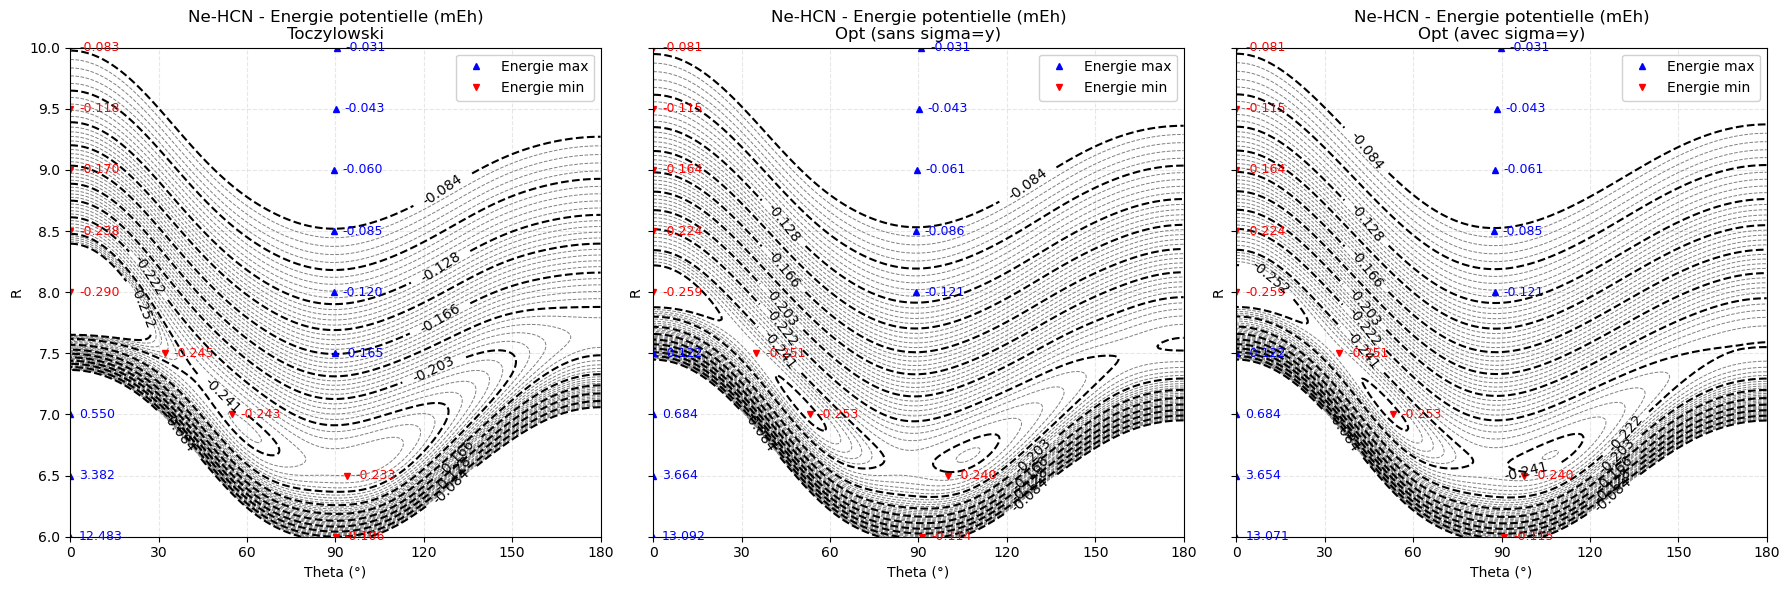

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

contour_plot(axes[0], params_Ne, "Toczylowski")
contour_plot(axes[1], params_opt_cf, "Opt (sans sigma=y)")
contour_plot(axes[2], params_opt_cf_sigma, "Opt (avec sigma=y)")

plt.tight_layout()

# Méthode 2 : least_squares

In [21]:
def residus_Ne(params):
    V_pred = V_opt(params, Ne["R"], Ne["Theta"])
    # .ravel() force le résultat en un tableau 1D pour least_squares
    return (V_pred - Ne["Energy_mEh"]).ravel()

In [22]:
result1 = least_squares(residus_Ne, params_Ne)
params_opt_ls = result1.x

result2 = least_squares(residus_Ne, params_Ne, x_scale = "jac")
params_opt_ls_jac = result2.x

In [23]:
result3 = least_squares(residus_Ne, params_Ne, 
                        x_scale = "jac", loss="soft_l1")
params_opt_ls_jac_soft = result3.x

In [24]:
result4 = least_squares(residus_Ne, params_Ne, 
                        x_scale = "jac", loss="huber")
params_opt_ls_jac_huber = result4.x

In [25]:
V_pred_ls = V_opt(params_opt_ls, R, Theta)
V_pred_ls_jac = V_opt(params_opt_ls_jac, R, Theta)
V_pred_ls_jac_soft = V_opt(params_opt_ls_jac_soft, R, Theta)
V_pred_ls_jac_huber = V_opt(params_opt_ls_jac_huber, R, Theta)

r2_ls = rsq(V_table, V_pred_ls)
r2_ls_jac = rsq(V_table, V_pred_ls_jac)
r2_ls_jac_soft = rsq(V_table, V_pred_ls_jac_soft)
r2_ls_jac_huber = rsq(V_table, V_pred_ls_jac_huber)

rmse_ls = rmse(V_table, V_pred_ls)
rmse_ls_jac = rmse(V_table, V_pred_ls_jac)
rmse_ls_jac_soft = rmse(V_table, V_pred_ls_jac_soft)
rmse_ls_jac_huber = rmse(V_table, V_pred_ls_jac_huber)

mae_ls = mae(V_table, V_pred_ls)
mae_ls_jac = mae(V_table, V_pred_ls_jac)
mae_ls_jac_soft = mae(V_table, V_pred_ls_jac_soft)
mae_ls_jac_huber = mae(V_table, V_pred_ls_jac_huber)

print(f"R²                                   : {r2_ls}")
print(f"R²   (x_scale='jac')                 : {r2_ls_jac}")
print(f"R²   (x_scale='jac', 'loss=soft_l1') : {r2_ls_jac_soft}")
print(f"R²   (x_scale='jac', 'loss=huber')   : {r2_ls_jac_huber}")
print()
print(f"rmse                                 : {rmse_ls}")
print(f"rmse (x_scale='jac')                 : {rmse_ls_jac}")
print(f"rmse (x_scale='jac', loss='soft_l1') : {rmse_ls_jac_soft}")
print(f"rmse (x_scale='jac', loss='huber')   : {rmse_ls_jac_huber}")
print()
print(f"mae                                  : {mae_ls}")
print(f"mae  (x_scale='jac')                 : {mae_ls_jac}")
print(f"mae  (x_scale='jac', loss='soft_l1') : {mae_ls_jac_soft}")
print(f"mae  (x_scale='jac', loss='huber')   : {mae_ls_jac_huber}")

R²                                   : 0.999999950352658
R²   (x_scale='jac')                 : 0.999999953554063
R²   (x_scale='jac', 'loss=soft_l1') : 0.9999999535540632
R²   (x_scale='jac', 'loss=huber')   : 0.999999953554063

rmse                                 : 0.0005731255527873221
rmse (x_scale='jac')                 : 0.0005543392564643014
rmse (x_scale='jac', loss='soft_l1') : 0.000554339255621556
rmse (x_scale='jac', loss='huber')   : 0.0005543392564643014

mae                                  : 0.00042964695960459674
mae  (x_scale='jac')                 : 0.00042757010892739987
mae  (x_scale='jac', loss='soft_l1') : 0.0004275688780518012
mae  (x_scale='jac', loss='huber')   : 0.00042757010892739987


In [26]:
print(np.array2string(
    params_opt_ls_jac_soft,
    formatter={'float_kind': lambda x: f"{x:.12f}"}
))
print(np.array2string(
    params_opt_ls_jac_huber,
    formatter={'float_kind': lambda x: f"{x:.12f}"}
))

[1.379833431266 0.074709205648 0.114621741430 0.096639131947
 0.048247630041 -0.022461247533 -32839.060214190977 -206101.882246492576
 -16096.154395796402 -111550.895173912562 13.483577597177 0.682961005284
 2.296777903635 0.551569123501 0.339166379295 -0.022278387877
 0.108345803872 -0.050699152370 -0.054268749014 0.007083584277
 0.006095310111 0.002971535702 -0.034712595773 0.024025283596
 0.024500761496 -0.000796903556 -0.003010739789 -0.001926274905
 0.003826394233 -0.003679939638 -0.003526367370 0.000051609683
 0.000574082717 0.000330074902 -0.000155229997 0.000190787938
 0.000171282463 -0.000010859405 -0.000038322318 -0.000016002157]
[1.379832260511 0.074706904945 0.114620523894 0.096638808921
 0.048247312096 -0.022461305610 -32839.074075450160 -206103.111572914902
 -16096.214657416351 -111551.410648002624 13.482557453176 0.682938230614
 2.296768250646 0.551567423781 0.339164592817 -0.022278938219
 0.108455943824 -0.050748927047 -0.054323405968 0.007090504506
 0.006101687154 0.00

In [27]:
R_vals = np.array([4.5,5.0,5.5,6.0,6.5,7.0,7.5,8.0,8.5,9.0,10.0,12.0])
x = np.linspace(0, 180, 180)
plot_interactif(V_opt, params_opt_ls, R_vals, x, Ne,
                fixed_col="R", x_col="Theta", y_col="Energy_mEh",
                title="Courbes à R fixé sans x_scale='jac'")
plot_interactif(V_opt, params_opt_ls_jac, R_vals, x, Ne,
                fixed_col="R", x_col="Theta", y_col="Energy_mEh",
                title="Courbes à R fixé avec x_scale='jac'")

In [28]:
# 1. Données d'entrée
#R_list = [4.5, 5.0, 5.5, 6.0, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 10.0, 12.0]
R_list = [6.5,6.55,6.60,6.65,6.70,6.75,6.80,6.90, 7.0, 7.10,7.2,7.3,7.4,7.6,7.7,7.9,8.10]
#Theta_list = [0, 20, 40, 60, 80, 90, 100, 120, 140, 160, 180]
Theta_list = [0, 45, 50, 55, 60, 105, 107.5, 110, 115, 180]

# 2. Calcul des énergies (en mEh)
res = np.array([
    V_opt(params_Ne, np.full_like(Theta_list, r, dtype=float), Theta_list)
    for r in R_list
])

# 3. Conversion de toute la matrice en µEh d'un seul coup
res_uEh = res * 1000

# 4. Configuration de l'affichage
largeur_r = 10  # Largeur pour la colonne de gauche 'R \ Theta'
largeur_th = 12  # Largeur pour chaque colonne de données
nb_colonnes = len(Theta_list)

# Ligne de séparation (|-------...-------|)
ligne_separation = "|" + "-" * (largeur_r + nb_colonnes * (largeur_th + 1)) + "|"

# --- Début de l'affichage ---

print(ligne_separation)
# Entête
entete_cols = "".join(f" {th:>{largeur_th}}" for th in Theta_list)
print(f"|{'R \\ Theta':<{largeur_r}}{entete_cols} |")
print(ligne_separation)

# Remplissage des lignes de données
for i, r in enumerate(R_list):
    # Colonne R
    ligne_str = f"|  {r:<{largeur_r-2}.2f}|"

    # Parcours des valeurs précalculées pour cette ligne (ce R)
    for val_uEh in res_uEh[i]:
        # Affichage de la valeur à 4 décimales, calée à droite
        ligne_str += f" {val_uEh:>{largeur_th}.4f}"

    ligne_str += " |"
    print(ligne_str)

print(ligne_separation)

|--------------------------------------------------------------------------------------------------------------------------------------------|
|R \ Theta             0           45           50           55           60          105        107.5          110          115          180 |
|--------------------------------------------------------------------------------------------------------------------------------------------|
|  6.50    |    3382.2988      14.0820     -97.0857    -164.1202    -201.8521    -229.7301    -226.9627    -223.0400    -210.8297     552.2175 |
|  6.55    |    2920.5949     -30.9234    -126.3299    -182.9358    -213.9167    -233.1663    -231.1264    -228.1031    -218.2891     451.0648 |
|  6.60    |    2510.4811     -69.7739    -151.1573    -198.5103    -223.5258    -235.2533    -233.8519    -231.6198    -223.9211     361.6679 |
|  6.65    |    2146.6812    -103.1229    -172.0493    -211.2080    -230.9649    -236.1633    -235.3205    -233.7828    -227.9472     2